# Proyecto RappiPlus: de datos a decisiones de negocio

**Autor:** Edgar Antonio "Tony" Gonzalez Salgado

Este notebook desarrolla el análisis completo de RappiPlus siguiendo la lógica del proyecto:
evaluación de calidad de datos → rentabilidad → funnel de conversión → retención por
cohortes → test A/B → dashboard.

## 1. Cargar y validar la calidad de los datos
### 1.1 Carga de datos y vista rápida

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

orders = pd.read_csv('rappiplus_orders_raw.csv', encoding='latin-1')
catalog = pd.read_csv('rappiplus_catalog.csv', encoding='latin-1')
marketing = pd.read_csv('rappiplus_marketing_spend.csv', encoding='latin-1')

print('orders:', orders.shape)
print('catalog:', catalog.shape)
print('marketing:', marketing.shape)
orders.head()

orders: (25100, 12)
catalog: (7, 4)
marketing: (1620, 5)


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,22/05/2025,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,15/06/2025,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,02/05/2025,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,09/06/2025,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,30/03/2025,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [2]:
catalog.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [3]:
marketing.head()

,fecha,pais,id_campaña,canal,gasto
0,01/01/2025,Mexico,organic_Mexico,organic,2446.25
1,01/01/2025,Mexico,paid_search_Mexico,paid_search,2704.34
2,01/01/2025,Mexico,social_Mexico,social,2045.01
3,01/01/2025,Colombia,organic_Colombia,organic,2597.21
4,01/01/2025,Colombia,paid_search_Colombia,paid_search,1771.40


In [4]:
# Vista general de tipos de datos y nulos
print(orders.info())
print()
print(orders.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  str    
 1   id_usuario          25100 non-null  str    
 2   fecha_hora_pedido   25100 non-null  str    
 3   pais                24800 non-null  str    
 4   dispositivo         25080 non-null  str    
 5   fuente_referencia   25070 non-null  str    
 6   nombre_producto     25070 non-null  str    
 7   categoria_producto  25020 non-null  str    
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), str(8)
memory usage: 2.3 MB
None

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre

### 1.2 Revisión y calidad de datos

Hallazgos principales al explorar los 3 datasets:

- **Fechas** en formato texto `DD/MM/YYYY` en `orders` y `marketing` -> se convierten a `datetime`.
- **`pais`** tiene inconsistencias de mayúsculas/minúsculas (`Mexico`, `mexico`, `MEXICO`...) y algunos nulos.
- **`categoria_producto`** en `orders` no trae acentos (`Electronica`) mientras que `catalog` sí
  (`Electrónica`) -> se reconstruye la categoría desde el catálogo usando `nombre_producto`
  como llave, que es la fuente de verdad.
- **`canal`** en `marketing` tiene valores nulos, pero se puede inferir del `id_campaña`
  (formato `canal_pais`, ej. `social_Argentina`).
- **100 filas duplicadas** exactas en `orders`.
- **Cantidades inválidas**: hay pedidos con `cantidad` negativa o cero (probables devoluciones/errores)
  y outliers extremos (10,000-20,000 unidades) que no son creíbles para un pedido individual.
- **Consistencia de montos**: se valida que `monto_total ≈ precio_unitario * cantidad - monto_descuento`;
  las discrepancias significativas (>0.5) se recalculan.


In [5]:
# ---- 1) Fechas ----
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], format='%d/%m/%Y', errors='coerce')
marketing['fecha'] = pd.to_datetime(marketing['fecha'], format='%d/%m/%Y', errors='coerce')

# ---- 2) Normalizar texto: pais ----
orders['pais'] = orders['pais'].str.strip().str.title()
marketing['pais'] = marketing['pais'].str.strip().str.title()

# ---- 3) Normalizar categoria_producto usando el catálogo como fuente de verdad ----
mapa_categoria = catalog.set_index('nombre_producto')['categoria_producto'].to_dict()
orders['categoria_producto'] = orders['nombre_producto'].map(mapa_categoria)

# ---- 4) canal nulo -> se infiere del id_campaña ----
marketing['canal'] = marketing['canal'].fillna(
    marketing['id_campaña'].str.extract(r'^([a-z_]+)_[A-Za-z]+$')[0]
)

# ---- 5) Eliminar duplicados exactos ----
dup_orders = orders.duplicated().sum()
orders = orders.drop_duplicates()
dup_marketing = marketing.duplicated().sum()
marketing = marketing.drop_duplicates()
dup_catalog = catalog.duplicated().sum()
catalog = catalog.drop_duplicates()

# ---- 6) Nulos en campos críticos ----
antes = len(orders)
orders = orders.dropna(subset=['pais', 'dispositivo', 'fuente_referencia',
                                'nombre_producto', 'categoria_producto',
                                'cantidad', 'precio_unitario', 'monto_descuento',
                                'fecha_hora_pedido'])
nulos_eliminados = antes - len(orders)

# ---- 7) Cantidades inválidas (<=0 o >100 unidades = outlier) ----
antes = len(orders)
orders = orders[(orders['cantidad'] > 0) & (orders['cantidad'] <= 100)]
cantidad_eliminados = antes - len(orders)

# ---- 8) Consistencia de montos ----
orders['monto_calculado'] = (orders['precio_unitario'] * orders['cantidad'] - orders['monto_descuento']).round(2)
orders['diferencia_monto'] = (orders['monto_calculado'] - orders['monto_total']).abs()
inconsistentes = (orders['diferencia_monto'] > 0.5).sum()
orders.loc[orders['diferencia_monto'] > 0.5, 'monto_total'] = orders['monto_calculado']
orders = orders.drop(columns=['monto_calculado', 'diferencia_monto'])

print('Duplicados eliminados -> orders:', dup_orders, '| marketing:', dup_marketing, '| catalog:', dup_catalog)
print('Filas eliminadas por nulos:', nulos_eliminados)
print('Filas eliminadas por cantidad inválida:', cantidad_eliminados)
print('Filas con monto_total corregido:', inconsistentes)
print('Filas finales orders:', len(orders))

Duplicados eliminados -> orders: 100 | marketing: 0 | catalog: 0
Filas eliminadas por nulos: 400
Filas eliminadas por cantidad inválida: 10
Filas con monto_total corregido: 0
Filas finales orders: 24590


In [6]:
# Verificación final de calidad
print('Nulos restantes orders:\n', orders.isna().sum())
print()
print('Nulos restantes marketing:\n', marketing.isna().sum())
print()
print('Valores únicos de pais (orders):', orders['pais'].unique())
print('Rango cantidad:', orders['cantidad'].min(), '-', orders['cantidad'].max())
print('Rango monto_total:', orders['monto_total'].min(), '-', orders['monto_total'].max())

Nulos restantes orders:
 id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64

Nulos restantes marketing:
 fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64

Valores únicos de pais (orders): <StringArray>
['Argentina', 'Mexico', 'Colombia']
Length: 3, dtype: str
Rango cantidad: 1.0 - 2.0
Rango monto_total: 5.24 - 999.89


**Exportación de los datasets limpios** para usarlos en las siguientes etapas del proyecto.

In [7]:
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)
print('Archivos exportados: orders_clean.csv, catalog_clean.csv, marketing_clean.csv')

Archivos exportados: orders_clean.csv, catalog_clean.csv, marketing_clean.csv


## 2. Analizar si el negocio es rentable
### 2.1 Cálculo de KPIs principales

In [8]:
orders = pd.read_csv('orders_clean.csv', parse_dates=['fecha_hora_pedido'])
catalog = pd.read_csv('catalog_clean.csv')
marketing = pd.read_csv('marketing_clean.csv', parse_dates=['fecha'])

orders = orders.merge(catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')
orders['costo_total_orden'] = orders['costo_unitario'] * orders['cantidad']

**Parte 1: Rentabilidad del negocio**

In [9]:
revenue_total = orders['monto_total'].sum()
costo_total = orders['costo_total_orden'].sum()
inversion_marketing = marketing['gasto'].sum()
profit = revenue_total - costo_total - inversion_marketing
margen_pct = profit / revenue_total * 100

print(f'Ingreso total (revenue):     ${revenue_total:,.2f}')
print(f'Costo total (COGS):          ${costo_total:,.2f}')
print(f'Inversión en marketing:      ${inversion_marketing:,.2f}')
print(f'Profit:                      ${profit:,.2f}')
print(f'Margen de profit:            {margen_pct:.2f}%')

Ingreso total (revenue):     $9,491,675.14
Costo total (COGS):          $3,783,478.80
Inversión en marketing:      $2,871,843.53
Profit:                      $2,836,352.81
Margen de profit:            29.88%


**Parte 2: Comportamiento de ventas**

In [10]:
ticket_promedio = orders['monto_total'].mean()
productos_promedio = orders['cantidad'].mean()
ventas_por_producto = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)
producto_top = ventas_por_producto.idxmax()
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)

print(f'Ticket promedio por orden: ${ticket_promedio:,.2f}')
print(f'Cantidad promedio de productos por orden: {productos_promedio:.2f}')
print(f'Producto más vendido: {producto_top} ({ventas_por_producto.max():,.0f} unidades)')
print()
print('Inversión en marketing por canal:')
print(gasto_por_canal)

Ticket promedio por orden: $386.00
Cantidad promedio de productos por orden: 1.51
Producto más vendido: Vacuum-Pro-Black (6,203 unidades)

Inversión en marketing por canal:
canal
social         976818.37
organic        972650.96
paid_search    922374.20
Name: gasto, dtype: float64


**KPIs adicionales de apoyo (revenue por país, categoría y mes)** — útiles para la narrativa ejecutiva (SCQA).

In [11]:
revenue_por_pais = orders.groupby('pais')['monto_total'].sum().sort_values(ascending=False)
revenue_por_categoria = orders.groupby('categoria_producto')['monto_total'].sum().sort_values(ascending=False)
revenue_mensual = orders.set_index('fecha_hora_pedido').resample('ME')['monto_total'].sum()

print('Revenue por país:\n', revenue_por_pais, '\n')
print('Revenue por categoría:\n', revenue_por_categoria, '\n')
print('Revenue por mes:\n', revenue_mensual)

Revenue por país:
 pais
Mexico       3204648.35
Colombia     3166869.70
Argentina    3120157.09
Name: monto_total, dtype: float64 

Revenue por categoría:
 categoria_producto
Hogar          3190241.62
Electrónica    3170376.62
Moda           3131056.90
Name: monto_total, dtype: float64 

Revenue por mes:
 fecha_hora_pedido
2025-01-31    1631348.68
2025-02-28    1425045.61
2025-03-31    1637758.30
2025-04-30    1576579.79
2025-05-31    1625007.48
2025-06-30    1595935.28
Freq: ME, Name: monto_total, dtype: float64


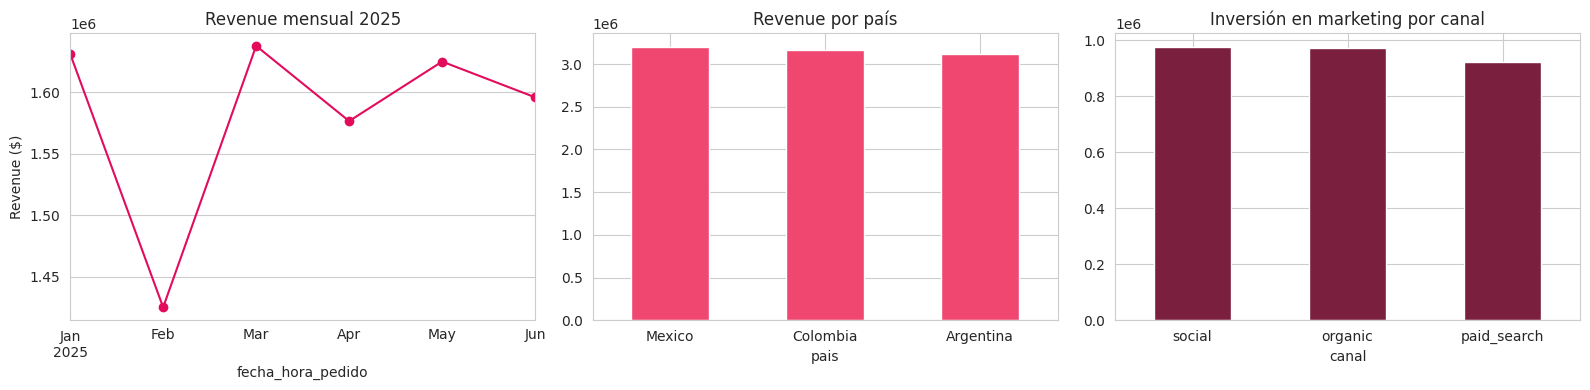

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

revenue_mensual.plot(kind='line', marker='o', ax=axes[0], color='#E30B5C')
axes[0].set_title('Revenue mensual 2025')
axes[0].set_ylabel('Revenue ($)')

revenue_por_pais.plot(kind='bar', ax=axes[1], color='#F04770')
axes[1].set_title('Revenue por país')
axes[1].tick_params(axis='x', rotation=0)

gasto_por_canal.plot(kind='bar', ax=axes[2], color='#7A1F3D')
axes[2].set_title('Inversión en marketing por canal')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('kpis_overview.png', dpi=120)
plt.show()

## 3. Entender dónde se pierden los usuarios (funnel de conversión)

> ⚠️ **Nota importante:** esta etapa requiere conexión a la base de datos PostgreSQL
> (`events`, `users`, `user_activity`) provista por Practicum/TripleTen. El entorno donde
> se generó este notebook **no tiene acceso de red a ese servidor** (`yp-trainers-practicum...`),
> por lo que las consultas SQL de abajo están **redactadas y listas para ejecutar**, pero no
> se corrieron aquí. Ejecuta este notebook en Jupyter/Colab con acceso a la base de datos del
> curso para obtener los resultados.

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'], db_config['pwd'], db_config['host'], db_config['port'], db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode': 'require'})

query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

**Parte 1: Totales del funnel** — usuarios únicos por evento, ordenados según el flujo
esperado (ej. `app_open` → `product_view` → `add_to_cart` → `checkout_start` → `purchase`).
Ajusta los nombres de `nombre_evento` a los reales de tu tabla `events`.

In [ ]:
query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

**Parte 2: Conversión entre pasos del funnel** usando `LAG()` para comparar cada etapa con la anterior.

In [ ]:
query_conversion = '''
WITH funnel AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos
    FROM events
    GROUP BY nombre_evento
),
ordenado AS (
    SELECT
        nombre_evento,
        usuarios_unicos,
        LAG(usuarios_unicos) OVER (ORDER BY usuarios_unicos DESC) AS usuarios_paso_anterior
    FROM funnel
)
SELECT
    nombre_evento,
    usuarios_unicos,
    usuarios_paso_anterior,
    ROUND(100.0 * usuarios_unicos / NULLIF(usuarios_paso_anterior, 0), 2) AS tasa_conversion_pct
FROM ordenado
ORDER BY usuarios_unicos DESC;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

**Interpretación esperada:** identifica la etapa con la mayor caída de `tasa_conversion_pct`
(el "cuello de botella" del funnel) y calcula la tasa de conversión final como
`usuarios en la última etapa / usuarios en la primera etapa * 100`.

## 4. Evaluar si los usuarios regresan (retención por cohortes)

> ⚠️ Igual que en el paso anterior, esta sección requiere la conexión a la base de datos
> (`users`, `user_activity`). Consultas listas para ejecutar en un entorno con acceso.

In [ ]:
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

In [ ]:
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

In [ ]:
query_cohort_retention_final = '''
WITH cohortes AS (
    SELECT
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS mes_cohorte
    FROM users
),
actividad AS (
    SELECT
        ua.id_usuario,
        c.mes_cohorte,
        CAST(ua.fecha_actividad AS DATE) AS fecha_actividad,
        FLOOR(
            (CAST(ua.fecha_actividad AS DATE) - CAST(u.fecha_registro AS DATE)) / 7.0
        ) AS semana_desde_registro
    FROM user_activity ua
    JOIN users u ON u.id_usuario = ua.id_usuario
    JOIN cohortes c ON c.id_usuario = ua.id_usuario
),
tamano_cohorte AS (
    SELECT mes_cohorte, COUNT(DISTINCT id_usuario) AS clientes_iniciales
    FROM cohortes
    GROUP BY mes_cohorte
),
retenidos AS (
    SELECT
        mes_cohorte,
        COUNT(DISTINCT id_usuario) FILTER (WHERE semana_desde_registro = 1) AS retenido_w1,
        COUNT(DISTINCT id_usuario) FILTER (WHERE semana_desde_registro = 2) AS retenido_w2,
        COUNT(DISTINCT id_usuario) FILTER (WHERE semana_desde_registro = 3) AS retenido_w3
    FROM actividad
    GROUP BY mes_cohorte
)
SELECT
    t.mes_cohorte,
    t.clientes_iniciales,
    r.retenido_w1,
    r.retenido_w2,
    r.retenido_w3,
    ROUND(100.0 * r.retenido_w1 / NULLIF(t.clientes_iniciales, 0), 2) AS semana_1,
    ROUND(100.0 * r.retenido_w2 / NULLIF(t.clientes_iniciales, 0), 2) AS semana_2,
    ROUND(100.0 * r.retenido_w3 / NULLIF(t.clientes_iniciales, 0), 2) AS semana_3
FROM tamano_cohorte t
JOIN retenidos r ON r.mes_cohorte = t.mes_cohorte
ORDER BY t.mes_cohorte;
'''

cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

## 5. Validar si los cambios generan impacto (test estadístico)

> ⚠️ Esta sección necesita el archivo **`experiment_checkout_ui.csv`**, que no fue
> incluido entre los archivos que compartiste. Sube ese archivo y vuelve a correr esta
> sección para obtener el resultado real; el código de abajo ya está listo.

**Hipótesis estadística**

- **H₀ (nula):** la tasa de conversión es igual entre el grupo de control y el grupo con
  el nuevo diseño de checkout (no hay diferencia real, la variación observada es azar).
- **H₁ (alternativa):** la tasa de conversión es distinta entre el grupo de control y el
  grupo con el nuevo diseño de checkout.
- **Test estadístico:** prueba de proporciones de dos muestras (**test z para dos proporciones**),
  ya que `conversion` es una variable binaria (0/1) y se comparan dos grupos independientes.
  Alternativa equivalente: **Chi-cuadrado de independencia** sobre la tabla de contingencia
  grupo × conversión.
- **Nivel de significancia:** α = 0.05.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

experiment = pd.read_csv('experiment_checkout_ui.csv')
print(experiment.head())
print(experiment['group'].value_counts())  # ajusta el nombre de columna de grupo si difiere

# Conteos de éxito (compras) y tamaño de muestra por grupo
resumen = experiment.groupby('group')['conversion'].agg(['sum', 'count'])
print(resumen)

conteo_exitos = resumen['sum'].values
tamanos = resumen['count'].values

z_stat, p_value = proportions_ztest(count=conteo_exitos, nobs=tamanos)

print(f'Estadístico z: {z_stat:.4f}')
print(f'p-value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('Se rechaza H0: hay una diferencia estadísticamente significativa en la conversión.')
else:
    print('No se rechaza H0: no hay evidencia suficiente de una diferencia en la conversión.')

## 6. Próximos pasos

- Conectar este notebook a la base de datos del curso para completar los pasos 3 y 4 (funnel y retención).
- Subir `experiment_checkout_ui.csv` para correr el test de hipótesis del paso 5.
- Con los resultados completos, construir el dashboard en la herramienta de BI (Tableau/Power BI)
  usando la estructura SCQA: **Situación** (RappiPlus ya es rentable, margen ~30%),
  **Complicación** (¿dónde se pierden usuarios / hay estacionalidad?), **Pregunta** (¿qué palancas
  mueven más el profit?), **Respuesta** (recomendación accionable basada en datos).